# Importing and downloading dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!wget -O /content/medical_dataset.zip https://zenodo.org/records/8382160/files/CT_Spine_dataset.zip?download=1

--2026-06-13 19:47:00--  https://zenodo.org/records/8382160/files/CT_Spine_dataset.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.184.103.118, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 497181610 (474M) [application/octet-stream]
Saving to: ‘/content/medical_dataset.zip’

/content/medical_da 100%[===================>] 474.15M  18.1MB/s    in 28s     

2026-06-13 19:47:29 (17.2 MB/s) - ‘/content/medical_dataset.zip’ saved [497181610/497181610]



## Extracting File

In [ ]:
import zipfile
import os

zip_path = "/content/medical_dataset.zip"
extract_dir = "/content/medical_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted to:", extract_dir)

Extracted to: /content/medical_dataset


In [ ]:
!pip install gdown tensorflow matplotlib

# Importing important ibraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (auto-split)

In [ ]:
extract_dir="/content/medical_dataset"

dataset = tf.keras.utils.image_dataset_from_directory(
    extract_dir,
    labels='inferred',
    label_mode='int',
    color_mode='grayscale',
    image_size=(128, 128),
    batch_size=16,
    validation_split=0.2,
    subset="both",
    seed=42
)

train_ds, val_ds = dataset
train_ds = train_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 5035 files belonging to 1 classes.
Using 4028 files for training.
Using 1007 files for validation.


# Define Sobel kernels

In [ ]:
sobel_x = np.array([[-1., 0., 1.],
                    [-2., 0., 2.],
                    [-1., 0., 1.]], dtype=np.float32)

sobel_y = np.array([[-1., -2., -1.],
                    [ 0.,  0.,  0.],
                    [ 1.,  2.,  1.]], dtype=np.float32)

weight = np.zeros((3, 3, 1, 2), dtype=np.float32)
weight[:, :, 0, 0] = sobel_x
weight[:, :, 0, 1] = sobel_y

# Build CNN model

In [ ]:
inputs = tf.keras.Input(shape=(128, 128, 1))

# 1️⃣ Sobel-initialized conv (trainable)
sobel_conv = tf.keras.layers.Conv2D(
    filters=2,
    kernel_size=3,
    padding="same",
    use_bias=False,
    name="sobel_layer"
)(inputs)

# 2️⃣ Subsequent trainable layers
x = tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same')(sobel_conv)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)  # binary classification

model = tf.keras.Model(inputs, outputs)

# Initialize Sobel weights — but leave layer trainable
model.get_layer("sobel_layer").set_weights([weight])

# Compile and train

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.9978 - loss: 0.0287 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/ste

# Inspect the first Sobel filter after training

In [ ]:
trained_weights = model.get_layer("sobel_layer").get_weights()[0]
print("Original Sobel X first row:", sobel_x[0])
print("Trained filter X first row :", trained_weights[0,:,0,0])
print("Original Sobel Y first row:", sobel_y[0])
print("Trained filter Y first row :", trained_weights[0,:,0,1])

Original Sobel X first row: [-1.  0.  1.]
Trained filter X first row : [-0.99399453  0.00600546  1.0060049 ]
Original Sobel Y first row: [-1. -2. -1.]
Trained filter Y first row : [-1.0060049 -2.0060048 -1.0060049]


# edge visualization

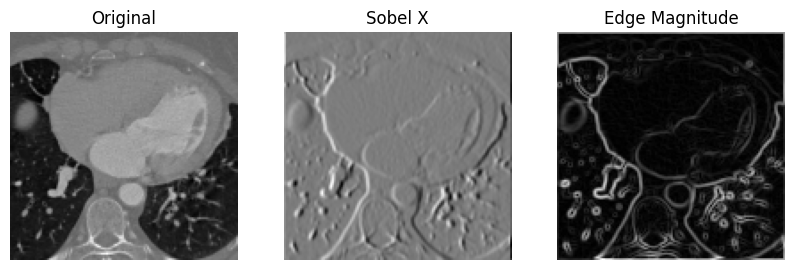

In [ ]:
import random

for images, labels in val_ds.take(1):
    # Pick a random index from the current batch
    rand_idx = random.randint(0, images.shape[0] - 1)
    img = images[rand_idx:rand_idx + 1]
    label = labels[rand_idx].numpy()

    #Applying Sobel Filter
    edges = model.get_layer("sobel_layer")(img)
    edges = edges.numpy()[0]
    edge_magnitude = np.sqrt(edges[:,:,0]**2 + edges[:,:,1]**2)

    #Plot of original image
    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.imshow(img[0,:,:,0], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    #plot of Sobel filter
    plt.subplot(1,3,2)
    plt.imshow(edges[:,:,0], cmap='gray')
    plt.title("Sobel X")
    plt.axis('off')

    #plot of Edge detected Output image
    plt.subplot(1,3,3)
    plt.imshow(edge_magnitude, cmap='gray')
    plt.title("Edge Magnitude")
    plt.axis('off')
    plt.show()
    break



#Comparing Classical Sobel filter with this Trained Sobel with CNN

Mean difference from classical Sobel: 12.320309


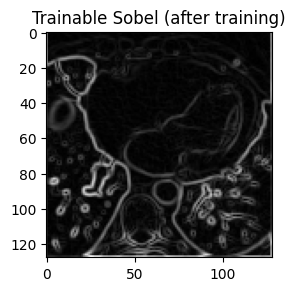

In [ ]:
from scipy import ndimage

# classical Sobel on the same image
sobel_x_fixed = ndimage.sobel(img[0,:,:,0], axis=1)
sobel_y_fixed = ndimage.sobel(img[0,:,:,0], axis=0)
sobel_mag_fixed = np.sqrt(sobel_x_fixed**2 + sobel_y_fixed**2)

# compute difference
diff = np.mean(np.abs(sobel_mag_fixed - edge_magnitude))
print("Mean difference from classical Sobel:", diff)

# plt.figure(figsize=(10,4))
# plt.subplot(1,2,1)
# plt.imshow(sobel_mag_fixed, cmap='gray')
# plt.title("Classical Sobel")

plt.subplot(1,2,2)
plt.imshow(edge_magnitude, cmap='gray')
plt.title("Trainable Sobel (after training)")
plt.show()



# **Text → Binary**

In [ ]:
def text_to_binary(text):
    return ''.join(format(ord(char), '08b') for char in text)

# **Embed Message Using Alternating 2nd LSB**

In [ ]:
def embed_message_2nd_lsb(edge_image, secret_text, edge_positions):

    stego = edge_image.copy()

    secret_text += "#####"

    binary_message = ''.join(
        format(ord(c), '08b')
        for c in secret_text
    )

    bit_index = 0

    for i, (row, col) in enumerate(edge_positions):

        if bit_index >= len(binary_message):
            break

        if i % 2 == 0:

            pixel = int(stego[row, col])

            bit = int(binary_message[bit_index])

            pixel = pixel & 0xFD

            pixel = pixel | (bit << 1)

            stego[row, col] = np.uint8(pixel)

            bit_index += 1

    print("Embedded bits:", bit_index)

    return stego

# **Extract Message**

In [ ]:
def extract_message_2nd_lsb(stego_image, edge_positions):

    binary_data = ""

    for i, (row, col) in enumerate(edge_positions):

        if i % 2 == 0:

            pixel = int(stego_image[row, col])

            bit = (pixel >> 1) & 1

            binary_data += str(bit)

    text = ""

    for i in range(0, len(binary_data), 8):

        byte = binary_data[i:i+8]

        if len(byte) < 8:
            break

        char = chr(int(byte, 2))

        text += char

        if text.endswith("#####"):
            return text[:-5]

    return text

# **Use with Your Edge Image**

After:

In [ ]:
edge_magnitude = np.sqrt(
    edges[:,:,0]**2 +
    edges[:,:,1]**2
)

Convert to uint8:

In [ ]:
edge_uint8 = (255 * edge_magnitude /
              edge_magnitude.max()).astype(np.uint8)

Create positions

In [ ]:
edge_positions = np.argwhere(edge_uint8 > 50)

Hide text:

In [ ]:
secret = input("Enter the secret message:")

stego_image = embed_message_2nd_lsb(
    edge_uint8,
    secret,
    edge_positions
)

Enter the secret message:Sayandip
Embedded bits: 104


# **Display Result**

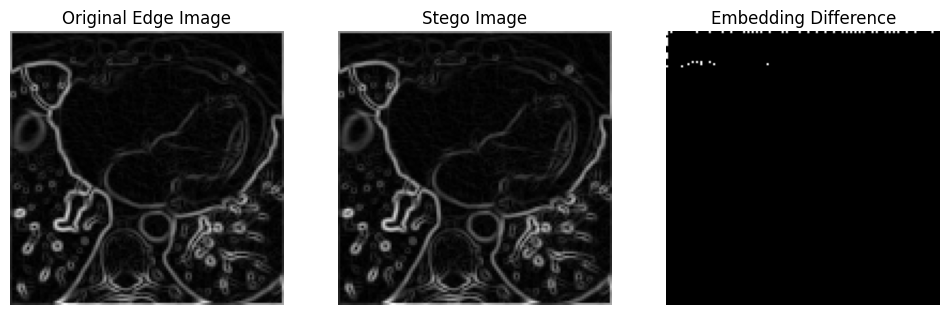

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(edge_uint8, cmap='gray')
plt.title("Original Edge Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(stego_image, cmap='gray')
plt.title("Stego Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(
    np.abs(
        stego_image.astype(int)
        - edge_uint8.astype(int)
    ),
    cmap='gray'
)
plt.title("Embedding Difference")
plt.axis('off')

plt.show()

# **Recover text:**

In [ ]:
recovered = extract_message_2nd_lsb(
    stego_image,
    edge_positions
)
from IPython.display import display, HTML

display(HTML(
    f"Recovered Text:<b> {recovered}</b>"
))

# PSNR Code

In [ ]:
import numpy as np

# Mean Squared Error
mse = np.mean(
    (edge_uint8.astype(np.float64) -
     stego_image.astype(np.float64)) ** 2
)

# PSNR
if mse == 0:
    psnr = float('inf')
else:
    psnr = 10 * np.log10((255 ** 2) / mse)

print("MSE :", mse)
print("PSNR:", psnr, "dB")

MSE : 0.0126953125
PSNR: 67.09436965200885 dB


#1st LSB Embedding Function

In [ ]:
import numpy as np

def embed_message_1st_lsb(edge_image, secret_text, edge_positions):

    stego = edge_image.copy()

    secret_text += "#####"

    binary_message = ''.join(
        format(ord(c), '08b')
        for c in secret_text
    )

    bit_index = 0

    for i, (row, col) in enumerate(edge_positions):

        if bit_index >= len(binary_message):
            break

        if i % 2 == 0:

            pixel = int(stego[row, col])

            bit = int(binary_message[bit_index])

            # Clear 1st LSB
            pixel = pixel & 0xFE

            # Set 1st LSB
            pixel = pixel | bit

            stego[row, col] = np.uint8(pixel)

            bit_index += 1

    print("Embedded bits:", bit_index)

    return stego

# Generate 1st-LSB Stego Image

In [ ]:
edge_positions = np.argwhere(edge_uint8 > 50)

stego_1st = embed_message_1st_lsb(
    edge_uint8,
    secret,
    edge_positions
)

Embedded bits: 104


# 1st LSB Extraction

In [ ]:
def extract_message_1st_lsb(stego_image, edge_positions):

    binary_data = ""

    for i, (row, col) in enumerate(edge_positions):

        if i % 2 == 0:

            pixel = int(stego_image[row, col])

            # Read 1st LSB
            bit = pixel & 1

            binary_data += str(bit)

    text = ""

    for i in range(0, len(binary_data), 8):

        byte = binary_data[i:i+8]

        if len(byte) < 8:
            break

        char = chr(int(byte, 2))

        text += char

        # Stop at delimiter
        if text.endswith("#####"):
            return text[:-5]

    return text

# Calculate PSNR

In [ ]:
mse_1st = np.mean(
    (edge_uint8.astype(np.float64)
     - stego_1st.astype(np.float64)) ** 2
)

if mse_1st == 0:
    psnr_1st = float('inf')
else:
    psnr_1st = 10 * np.log10((255**2) / mse_1st)

print("1st LSB MSE :", mse_1st)
print("1st LSB PSNR:", psnr_1st, "dB")

1st LSB MSE : 0.00225830078125
1st LSB PSNR: 74.59298576096651 dB


# Comparison

In [ ]:
print("\n===== COMPARISON =====")
print("1st LSB PSNR :", round(psnr_1st, 4), "dB")
print("2nd LSB PSNR :", round(psnr, 4), "dB")

if psnr_1st > psnr:
    print("1st LSB gives better image quality.")
else:
    print("2nd LSB gives better image quality.")


===== COMPARISON =====
1st LSB PSNR : 74.593 dB
2nd LSB PSNR : 67.0944 dB
1st LSB gives better image quality.


# Noise introduced

In [ ]:
'''import numpy as np

def lsb_plane_noise(image, probability=0.2):
    noisy = image.copy()

    mask = np.random.rand(*image.shape) < probability

    noisy[mask] = noisy[mask] ^ 1

    return noisy'''
import numpy as np

def add_small_noise(image, probability=0.1):

    noisy = image.copy().astype(np.int16)

    mask = np.random.rand(*image.shape) < probability

    noise = np.random.choice(
        [-1, 1],
        size=image.shape
    )

    noisy[mask] += noise[mask]

    noisy = np.clip(noisy, 0, 255)

    return noisy.astype(np.uint8)

# Noisy image

In [ ]:
noisy_1st = add_small_noise(stego_1st, 0.01)
noisy_2nd = add_small_noise(stego_image, 0.01)

# Recover Message

In [ ]:
msg_1st = extract_message_1st_lsb(
    noisy_1st,
    edge_positions
)

msg_2nd = extract_message_2nd_lsb(
    noisy_2nd,
    edge_positions
)

print("1st LSB Recovery:")
print(msg_1st)

print("\n2nd LSB Recovery:")
print(msg_2nd)

1st LSB Recovery:
Sayandir###!#E£°¬v>mÚ%"V#¿[V®®2ønIqB ég5÷õúé¿®NqÔUAòûúí+UÌÜpp'ê>ÏL4æá<5oDèZ­õÑàpl±|ôü<î¬îGý¬Mçå|(EI{'nSëêýXjXó¢ù­ì¨pÑØ²ÿ

2nd LSB Recovery:
Sayandyp


Binary representation

In [ ]:
original_bits = ''.join(
    format(ord(c), '08b')
    for c in (secret + "#####")
)

print("Total bits:", len(original_bits))

Total bits: 104


# Extract Raw Bits (1st LSB)

In [ ]:
def extract_bits_1st_lsb(stego_image, edge_positions, n_bits):

    bits = ""

    for i, (row, col) in enumerate(edge_positions):

        if i % 2 == 0:

            pixel = int(stego_image[row, col])

            bit = pixel & 1

            bits += str(bit)

            if len(bits) >= n_bits:
                break

    return bits

# Extract Raw Bits (2nd LSB)

In [ ]:
def extract_bits_2nd_lsb(stego_image, edge_positions, n_bits):

    bits = ""

    for i, (row, col) in enumerate(edge_positions):

        if i % 2 == 0:

            pixel = int(stego_image[row, col])

            bit = (pixel >> 1) & 1

            bits += str(bit)

            if len(bits) >= n_bits:
                break

    return bits

# BER Function

In [ ]:
def calculate_ber(original_bits, recovered_bits):

    errors = 0

    for b1, b2 in zip(original_bits, recovered_bits):

        if b1 != b2:
            errors += 1

    ber = errors / len(original_bits)

    return ber, errors

# BER for 1st-LSB

In [ ]:
recovered_bits_1st = extract_bits_1st_lsb(
    noisy_1st,
    edge_positions,
    len(original_bits)
)

ber_1st, errors_1st = calculate_ber(
    original_bits,
    recovered_bits_1st
)

print("1st LSB Errors:", errors_1st)
print("1st LSB BER:", ber_1st)

1st LSB Errors: 2
1st LSB BER: 0.019230769230769232


# BER for 2nd-LSB

In [ ]:
recovered_bits_2nd = extract_bits_2nd_lsb(
    noisy_2nd,
    edge_positions,
    len(original_bits)
)

ber_2nd, errors_2nd = calculate_ber(
    original_bits,
    recovered_bits_2nd
)

print("2nd LSB Errors:", errors_2nd)
print("2nd LSB BER:", ber_2nd)

2nd LSB Errors: 1
2nd LSB BER: 0.009615384615384616


# Comparison Table

In [ ]:
print("\n===== BER COMPARISON =====")

print(f"1st LSB -> Errors: {errors_1st}, BER: {ber_1st:.4f}")

print(f"2nd LSB -> Errors: {errors_2nd}, BER: {ber_2nd:.4f}")


===== BER COMPARISON =====
1st LSB -> Errors: 2, BER: 0.0192
2nd LSB -> Errors: 1, BER: 0.0096
